# SaaS FP&A - Revenue Planning, Variance & Forecast Analysis

## Business Problem

Management wants to understand whether recurring revenue is performing according to plan, why actual performance differs from expectations, what future MRR could look like and what actions management should take.

## Purpose of the Project

To simulate a real-world FP&A analysis for a SaaS business by using account-level revenue data to evaluate historical MRR performance, build a driver-based revenue budget, analyze Actual vs Budget variances, forecast future revenue, assess Best/Base/Worst scenarios and provide data-driven recommendations to management.

In simple words: Understand what happened -> explain why -> predict what happens next -> recommend what management should do.

#### Project Goal

To determine whether the SaaS business is meeting its revenue expectations, identify the key drivers behind revenue performance, forecast future MRR, evaluate potential risks and opportunities and support management with actionable financial recommendations.

#### Phase 1 - Data Understanding

##### Load and Explore the Dataset

In [203]:
# Importing all the required libraries
# Data Manipulation
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Statistical Analysis
from scipy import stats
# Machine Learning / Forecast Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
# Display / Warnings
from IPython.display import display
import warnings
# Suppress unnecessary warnings
warnings.filterwarnings("ignore")

In [11]:
# Load the data
saas_data = pd.read_csv("Downloads/SaaS_Revenue_Forecasting_Dataset.csv")

In [13]:
# Display first 5 records
print("First 5 Records")
display(saas_data.head())

First 5 Records


,account_id,month,company_size,industry,contract_type,discount_pct,regime_state,active_users,usage_growth,feature_adoption_rate,error_rate,tickets_count,ticket_growth,payment_delay_flag,current_mrr,next_month_mrr
0,0,1,SMB,Energy,Monthly,0.054167,stable,4.765884,0.017574,0.002766,0.102689,0.0,0.0,0,112.703497,50.000000
1,0,2,SMB,Energy,Monthly,0.054167,stable,11.706351,0.027244,0.000000,0.102174,2.0,inf,1,50.000000,51.903945
2,0,3,SMB,Energy,Monthly,0.054167,decline,12.706351,0.004655,0.082195,0.195298,2.0,0.0,0,51.903945,50.000000
3,0,4,SMB,Energy,Monthly,0.054167,decline,17.393579,-0.024496,0.062898,0.104958,3.0,0.5,1,50.000000,55.680067
4,0,5,SMB,Energy,Monthly,0.054167,decline,20.607523,-0.073376,0.120356,0.076803,0.0,-1.0,0,55.680067,50.000000


In [15]:
# Dataset dimensions
rows, columns = saas_data.shape
print("Dataset Dimensions")
print(f"Rows    : {rows:,}")
print(f"Columns : {columns}")

Dataset Dimensions
Rows    : 1,150,000
Columns : 16


In [17]:
# Check data types
print("Data Types")
print(saas_data.dtypes)

Data Types
account_id                 int64
month                      int64
company_size              object
industry                  object
contract_type             object
discount_pct             float64
regime_state              object
active_users             float64
usage_growth             float64
feature_adoption_rate    float64
error_rate               float64
tickets_count            float64
ticket_growth            float64
payment_delay_flag         int64
current_mrr              float64
next_month_mrr           float64
dtype: object


In [19]:
# Missing value analysis
missing_values = saas_data.isnull().sum()
missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing %": (missing_values / len(saas_data) * 100).round(2)})
print("Missing Value Analysis")
display(missing_summary)

Missing Value Analysis


,Missing Values,Missing %
account_id,0,0.00
month,0,0.00
company_size,0,0.00
industry,0,0.00
contract_type,0,0.00
discount_pct,115240,10.02
regime_state,0,0.00
active_users,0,0.00
usage_growth,0,0.00
feature_adoption_rate,34376,2.99


In [21]:
# Check duplicate records
duplicate_count = saas_data.duplicated().sum()
print("Duplicate Record Analysis")
print(f"Duplicate records: {duplicate_count:,}")
print(f"Duplicate %     : {(duplicate_count / len(saas_data) * 100):.2f}%")

Duplicate Record Analysis
Duplicate records: 0
Duplicate %     : 0.00%


In [23]:
# DATASET PROFILE
print("SAAS DATASET PROFILE")
print(f"Total Records       : {len(saas_data):,}")
print(f"Total Variables     : {saas_data.shape[1]}")
print(f"Duplicate Records   : {saas_data.duplicated().sum():,}")
print(f"Total Missing Cells : {saas_data.isnull().sum().sum():,}")
print("\nColumn Names")
for i, column in enumerate(saas_data.columns, start=1):
    print(f"{i:2}. {column}")

SAAS DATASET PROFILE
Total Records       : 1,150,000
Total Variables     : 16
Duplicate Records   : 0
Total Missing Cells : 188,609

Column Names
 1. account_id
 2. month
 3. company_size
 4. industry
 5. contract_type
 6. discount_pct
 7. regime_state
 8. active_users
 9. usage_growth
10. feature_adoption_rate
11. error_rate
12. tickets_count
13. ticket_growth
14. payment_delay_flag
15. current_mrr
16. next_month_mrr


##### Data Understanding: Overview

The SaaS FP&A (Software as a Service - Financial Planning & Analysis) dataset is sufficiently large and structurally rich for a portfolio-level FP&A analysis. It provides financial, customer, subscription, usage, operational and payment variables that can be connected to recurring revenue performance. While there are no duplicate records, the dataset contains 188,609 missing cells, primarily concentrated in discount and customer-health variables. The presence of an infinite ticket-growth value also indicates that additional data-quality validation is required. Therefore, the dataset is suitable for analysis but should be cleaned and validated before developing KPIs, budgets, variance analysis, forecasts and management recommendations.

In [30]:
# BUSINESS VARIABLE CLASSIFICATION
variable_classification = {
    "Revenue Variables": ["current_mrr", "next_month_mrr"],
    "Customer / Account Variables": ["account_id", "company_size", "industry"],
    "Usage Variables": ["active_users", "usage_growth", "feature_adoption_rate"],
    "Contract / Commercial Variables": ["contract_type", "discount_pct"],
    "Risk / Customer Health Variables": ["regime_state", "error_rate", "tickets_count", "ticket_growth", "payment_delay_flag"]}
for category, variables in variable_classification.items():
    print(f"\n{category}")
    for variable in variables:
        print(f"• {variable}")


Revenue Variables
• current_mrr
• next_month_mrr

Customer / Account Variables
• account_id
• company_size
• industry

Usage Variables
• active_users
• usage_growth
• feature_adoption_rate

Contract / Commercial Variables
• contract_type
• discount_pct

Risk / Customer Health Variables
• regime_state
• error_rate
• tickets_count
• ticket_growth
• payment_delay_flag


### Phase 2 - Data Preparation

In [33]:
# DATA QUALITY & CLEANING
# Missing Value Analysis
missing_summary = pd.DataFrame({
    "Missing Values": saas_data.isna().sum(),
    "Missing %": (saas_data.isna().mean() * 100).round(2)})
missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values("Missing %", ascending=False)
print("Missing Value Summary")
display(missing_summary)

Missing Value Summary


,Missing Values,Missing %
discount_pct,115240,10.02
feature_adoption_rate,34376,2.99
tickets_count,22814,1.98
error_rate,16179,1.41


In [35]:
# Check for exact duplicate records
duplicate_count = saas_data.duplicated().sum()
print("Duplicate Record Check")
print(f"Duplicate records: {duplicate_count:,}")

Duplicate Record Check
Duplicate records: 0


In [37]:
# Check whether each account-month combination is unique
account_month_duplicates = (
    saas_data
    .duplicated(subset=["account_id", "month"])
    .sum())
print("Account-Month Uniqueness Check")
print(f"Duplicate account-month records: {account_month_duplicates:,}")

Account-Month Uniqueness Check
Duplicate account-month records: 0


In [39]:
# Check infinite values
numeric_columns = saas_data.select_dtypes(
    include=np.number
).columns
infinity_summary = pd.DataFrame({
    "Positive Infinity": np.isposinf(
        saas_data[numeric_columns]
    ).sum(),
    "Negative Infinity": np.isneginf(
        saas_data[numeric_columns]
    ).sum()})
infinity_summary = infinity_summary[
    (infinity_summary["Positive Infinity"] > 0) |
    (infinity_summary["Negative Infinity"] > 0)]
print("Infinite Value Check")
display(infinity_summary)

Infinite Value Check


,Positive Infinity,Negative Infinity
ticket_growth,68977,0


In [41]:
# Numerical range validation
range_check = saas_data[
    [
        "discount_pct",
        "active_users",
        "usage_growth",
        "feature_adoption_rate",
        "error_rate",
        "tickets_count",
        "ticket_growth",
        "current_mrr",
        "next_month_mrr"]].describe().T
print("Numerical Range Validation")
display(range_check)

Numerical Range Validation


,count,mean,std,min,25%,50%,75%,max
discount_pct,1034760.0,0.058306,0.036116,0.000285,0.030653,0.051782,0.079194,2.525988e-01
active_users,1150000.0,89.719993,76.135157,1.000000,34.518771,70.520137,122.381315,9.909708e+02
usage_growth,1150000.0,0.012803,0.036889,-0.149102,-0.012028,0.014375,0.038819,1.680977e-01
feature_adoption_rate,1115624.0,0.500057,0.339723,0.000000,0.165016,0.499969,0.835096,1.000000e+00
error_rate,1133821.0,0.103018,0.067043,0.000073,0.052176,0.089969,0.139840,6.461280e-01
tickets_count,1127186.0,4.898935,4.205786,0.000000,2.000000,4.000000,7.000000,4.300000e+01
ticket_growth,1150000.0,inf,NaN,-1.000000,-0.300000,0.000000,0.750000,inf
current_mrr,1150000.0,321.803629,1530.250893,20.015618,51.636993,69.135142,140.444116,1.716090e+05
next_month_mrr,1150000.0,289.703835,1597.272434,50.000000,51.293633,67.837514,128.255208,2.691279e+05


In [43]:
# Discount validation
invalid_discount = saas_data[
    (saas_data["discount_pct"] < 0) |
    (saas_data["discount_pct"] > 1)]
print("Discount Validation")
print(f"Invalid discount records: {len(invalid_discount):,}")

Discount Validation
Invalid discount records: 0


In [45]:
# Feature adoption validation
invalid_adoption = saas_data[
    (saas_data["feature_adoption_rate"] < 0) |
    (saas_data["feature_adoption_rate"] > 1)]
print("Feature Adoption Validation")
print(f"Invalid records: {len(invalid_adoption):,}")

Feature Adoption Validation
Invalid records: 0


In [47]:
# Error rate validation
invalid_error_rate = saas_data[
    (saas_data["error_rate"] < 0) |
    (saas_data["error_rate"] > 1)]
print("Error Rate Validation")
print(f"Invalid records: {len(invalid_error_rate):,}")

Error Rate Validation
Invalid records: 0


In [49]:
# Validate MRR values
mrr_validation = {
    "Negative Current MRR": (saas_data["current_mrr"] < 0).sum(),
    "Negative Next-Month MRR": (saas_data["next_month_mrr"] < 0).sum(),
    "Zero Current MRR": (saas_data["current_mrr"] == 0).sum(),
    "Zero Next-Month MRR": (saas_data["next_month_mrr"] == 0).sum()}
print("MRR Validation")
for check, count in mrr_validation.items():
    print(f"{check}: {count:,}")

MRR Validation
Negative Current MRR: 0
Negative Next-Month MRR: 0
Zero Current MRR: 0
Zero Next-Month MRR: 0


In [53]:
# Validate payment delay flag
payment_values = sorted(
    saas_data["payment_delay_flag"].dropna().unique())
print("Payment Delay Flag Values")
print(payment_values)

Payment Delay Flag Values
[0, 1]


In [55]:
# SAFE DATA CLEANING
# Replace infinite values with NaN
saas_data_clean = saas_data.replace(
    [np.inf, -np.inf],
    np.nan)
print("Infinite values replaced with NaN.")

Infinite values replaced with NaN.


In [57]:
# Final data-quality check
print("FINAL DATA QUALITY CHECK")
print(f"Rows: {len(saas_data_clean):,}")
print(f"Columns: {saas_data_clean.shape[1]:,}")
print(f"Duplicate rows: {saas_data_clean.duplicated().sum():,}")
print(
    f"Missing cells: "
    f"{saas_data_clean.isna().sum().sum():,}")
print(
    f"Infinite values: "
    f"{np.isinf(
        saas_data_clean.select_dtypes(include=np.number)
    ).sum().sum():,}")

FINAL DATA QUALITY CHECK
Rows: 1,150,000
Columns: 16
Duplicate rows: 0
Missing cells: 257,586
Infinite values: 0


Interpretation

The dataset is structurally reliable, with no duplicate account-month records, invalid MRR valus, or out-of-range percentage variables. Missing values and 68,977 undefined `ticket_growth` observations were identified and handled, making the dataset suitable for further FP&A analysis.

In [60]:
# FINANCIAL & BUSINESS METRICS
# Work with cleaned dataset
saas_data = saas_data_clean.copy()
# MRR change
saas_data["mrr_change"] = (
    saas_data["next_month_mrr"] -
    saas_data["current_mrr"])
# MRR growth %
saas_data["mrr_growth_pct"] = (
    saas_data["mrr_change"] /
    saas_data["current_mrr"]) * 100
# Average MRR per account
# At account-level, this represents the account's current MRR. Aggregate averages will be calculated later at the required level.
# Revenue per active user
saas_data["revenue_per_active_user"] = (
    saas_data["current_mrr"] /
    saas_data["active_users"])
# Discount-adjusted MRR
saas_data["discount_adjusted_mrr"] = (
    saas_data["current_mrr"] *
    (1 - saas_data["discount_pct"]))
# Display newly created metrics
metrics = [
    "current_mrr",
    "next_month_mrr",
    "mrr_change",
    "mrr_growth_pct",
    "active_users",
    "revenue_per_active_user",
    "discount_pct",
    "discount_adjusted_mrr"]
display(saas_data[metrics].head())

,current_mrr,next_month_mrr,mrr_change,mrr_growth_pct,active_users,revenue_per_active_user,discount_pct,discount_adjusted_mrr
0,112.703497,50.000000,-62.703497,-55.635804,4.765884,23.647974,0.054167,106.598644
1,50.000000,51.903945,1.903945,3.807890,11.706351,4.271186,0.054167,47.291631
2,51.903945,50.000000,-1.903945,-3.668209,12.706351,4.084882,0.054167,49.092444
3,50.000000,55.680067,5.680067,11.360134,17.393579,2.874624,0.054167,47.291631
4,55.680067,50.000000,-5.680067,-10.201257,20.607523,2.701929,0.054167,52.664024


In [62]:
# Check summary statistics of newly created metrics
metric_summary = saas_data[[
        "mrr_change",
        "mrr_growth_pct",
        "revenue_per_active_user",
        "discount_adjusted_mrr"]].describe().T
display(metric_summary)

,count,mean,std,min,25%,50%,75%,max
mrr_change,1150000.0,-32.099794,674.608138,-97522.797110,-6.024655,4.630752,16.642511,120384.570297
mrr_growth_pct,1150000.0,2.739774,27.850330,-99.881615,-7.271371,6.171613,19.999168,314.362824
revenue_per_active_user,1150000.0,10.354065,45.324529,0.069024,0.737681,1.170989,2.367705,2679.908157
discount_adjusted_mrr,1034760.0,303.558952,1450.126836,17.628885,49.363833,65.201962,132.225277,164261.711319


Interpretation: 
The created metrics capture MRR movement, growth, revenue efficieny, and the potential effect of discounts. The wide dispersion in MRR change and revenue per active user indicates substantial variation across accounts, which will be considered in the subsequent historical and segment-level analysis.

### Phase 3 - Historical Performance

In [66]:
# HISTORICAL MRR PERFORMANCE
monthly_mrr = (
    saas_data
    .groupby("month")
    .agg(
        total_current_mrr=("current_mrr", "sum"),
        total_next_month_mrr=("next_month_mrr", "sum"),
        accounts=("account_id", "nunique"),
        average_mrr_per_account=("current_mrr", "mean")).reset_index())
# Monthly MRR growth
monthly_mrr["mrr_growth_pct"] = (
    monthly_mrr["total_next_month_mrr"]
    .div(monthly_mrr["total_current_mrr"]).sub(1) * 100)
display(monthly_mrr.head())

,month,total_current_mrr,total_next_month_mrr,accounts,average_mrr_per_account,mrr_growth_pct
0,1,6.013696e+07,4.165627e+07,50000,1202.739147,-30.730993
1,2,4.201456e+07,2.561842e+07,50000,840.291175,-39.024901
2,3,2.583895e+07,1.658616e+07,50000,516.779091,-35.809465
3,4,1.670316e+07,1.224213e+07,50000,334.063159,-26.707676
4,5,1.234433e+07,9.881106e+06,50000,246.886602,-19.954294


In [68]:
# Display monthly performance summary
display(monthly_mrr)

,month,total_current_mrr,total_next_month_mrr,accounts,average_mrr_per_account,mrr_growth_pct
0,1,6.013696e+07,4.165627e+07,50000,1202.739147,-30.730993
1,2,4.201456e+07,2.561842e+07,50000,840.291175,-39.024901
2,3,2.583895e+07,1.658616e+07,50000,516.779091,-35.809465
3,4,1.670316e+07,1.224213e+07,50000,334.063159,-26.707676
4,5,1.234433e+07,9.881106e+06,50000,246.886602,-19.954294
5,6,9.947318e+06,8.527880e+06,50000,198.946356,-14.269558
6,7,8.565133e+06,7.795234e+06,50000,171.302669,-8.988762
7,8,7.905504e+06,7.444975e+06,50000,158.110085,-5.825422
8,9,7.489138e+06,7.216828e+06,50000,149.782751,-3.636055
9,10,7.264619e+06,7.424178e+06,50000,145.292376,2.196386


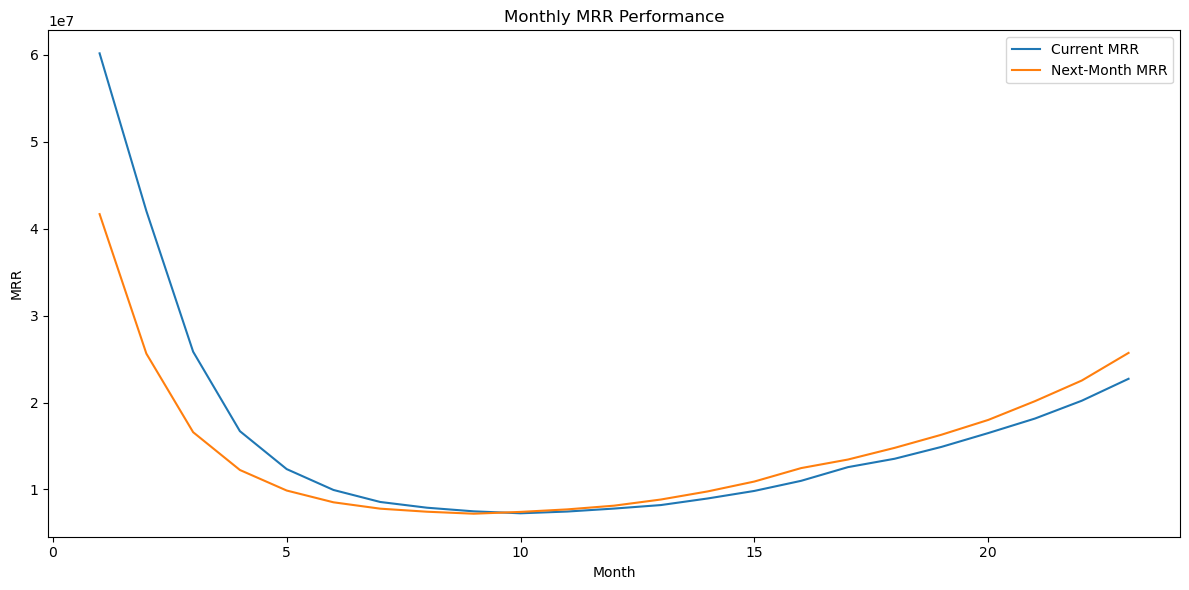

In [70]:
# MONTHLY MRR TREND
plt.figure(figsize=(12, 6))
plt.plot(monthly_mrr["month"], monthly_mrr["total_current_mrr"],label="Current MRR")
plt.plot(monthly_mrr["month"], monthly_mrr["total_next_month_mrr"], label="Next-Month MRR")

plt.title("Monthly MRR Performance")
plt.xlabel("Month")
plt.ylabel("MRR")
plt.legend()
plt.tight_layout()
plt.show()

In [80]:
# Overall historical performance
print("Historical MRR Performance")
print(
    f"Total Current MRR: "
    f"{monthly_mrr['total_current_mrr'].sum():,.2f}")
print(
    f"Average Monthly MRR: "
    f"{monthly_mrr['total_current_mrr'].mean():,.2f}")
print(
    f"Average MRR Growth: "
    f"{monthly_mrr['mrr_growth_pct'].mean():.2f}%")
print(
    f"Average MRR per Account: "
    f"{monthly_mrr['average_mrr_per_account'].mean():,.2f}")
print("\nInterpretation: MRR shows a strong recovery over time: after declining sharply in the early months,")
print("revenue reaches sustained positive growth from Month 10 onward, indicating improving SaaS revenue momentum.")

Historical MRR Performance
Total Current MRR: 370,074,173.00
Average Monthly MRR: 16,090,181.43
Average MRR Growth: -2.77%
Average MRR per Account: 321.80

Interpretation: MRR shows a strong recovery over time: after declining sharply in the early months,
revenue reaches sustained positive growth from Month 10 onward, indicating improving SaaS revenue momentum.


,total_mrr,accounts,average_mrr
industry,,,
EdTech,4.031731e+07,5026,348.771720
Energy,3.981847e+07,5011,345.487450
Consulting,3.774215e+07,5073,323.469952
SaaS,3.749114e+07,5038,323.550953
Logistics,3.663872e+07,5004,318.342876
Media,3.645414e+07,4995,317.309829
Retail,3.598353e+07,4939,316.764796
Fintech,3.585189e+07,4981,312.944751
Health,3.526808e+07,5008,306.189049


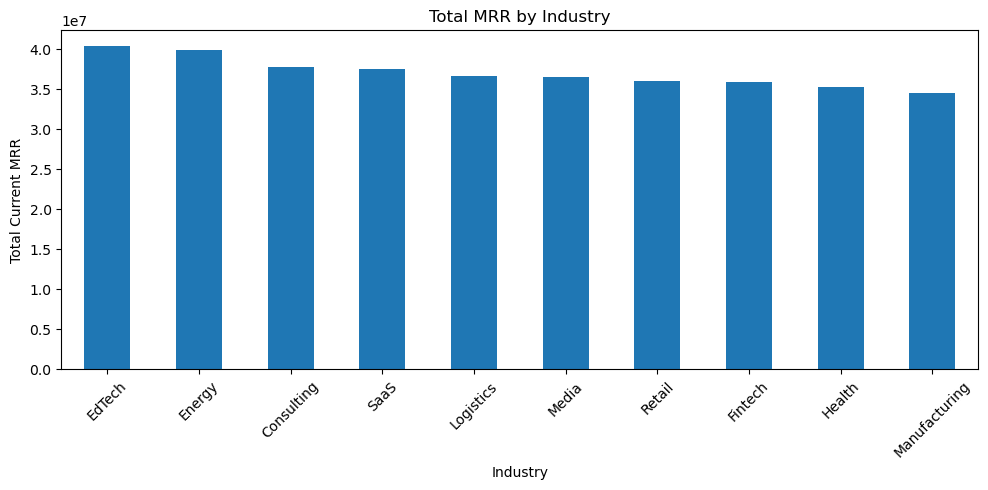

In [116]:
# REVENUE BY BUSINESS SEGMENT
# MRR BY INDUSTRY
industry_mrr = (
    saas_data
    .groupby("industry")
    .agg(
        total_mrr=("current_mrr", "sum"),
        accounts=("account_id", "nunique"),
        average_mrr=("current_mrr", "mean")
    )
    .sort_values("total_mrr", ascending=False)
)
display(industry_mrr)
# Visual
plt.figure(figsize=(10, 5))
industry_mrr["total_mrr"].plot(kind="bar")

plt.title("Total MRR by Industry")
plt.xlabel("Industry")
plt.ylabel("Total Current MRR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,total_mrr,accounts,average_mrr
company_size,,,
Enterprise,2.090709e+08,4977,1826.409055
Mid,8.465592e+07,14974,245.805549
SMB,7.634738e+07,30049,110.467945


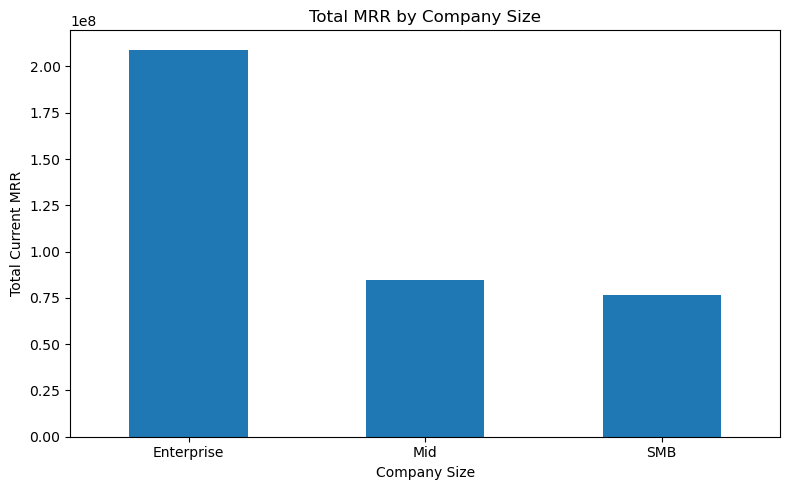

In [118]:
# MRR by Company Size
company_size_mrr = (
    saas_data
    .groupby("company_size")
    .agg(
        total_mrr=("current_mrr", "sum"),
        accounts=("account_id", "nunique"),
        average_mrr=("current_mrr", "mean")
    )
    .sort_values("total_mrr", ascending=False)
)
display(company_size_mrr)
# Visual
plt.figure(figsize=(8, 5))
company_size_mrr["total_mrr"].plot(kind="bar")

plt.title("Total MRR by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Total Current MRR")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [108]:
# MRR by Contract Type
contract_mrr = (
    saas_data
    .groupby("contract_type")
    .agg(
        total_mrr=("current_mrr", "sum"),
        accounts=("account_id", "nunique"),
        average_mrr=("current_mrr", "mean")
    )
    .sort_values("total_mrr", ascending=False)
)
display(contract_mrr)

,total_mrr,accounts,average_mrr
contract_type,,,
Monthly,2.122513e+08,46294,199.341535
Annual,1.578229e+08,3706,1851.555421


Interpretation: Enterprise customers contribute the most recurring revenue by company size, EdTech leads by industry, and Monthly contracts contribute the highest total MRR due to their larger customer base, while Annual contracts generate much higher average MRR per account.

### PHASE 3 - Historical Performance: Conclusion
- **Revenue Trend:** MRR declined sharply in the early months but recovered from Month 10 onward, showing sustained positive momentum.
-  **Customer Segment:** Enterprise customers contribute the largest share of recurring revenue.
-  **Industry:** EdTech is the highest-MRR industry, followed closely by Energy.
-  **Contract Type:** Monthly contracts generate higher total MRR due to their larger customer base, while Annual contracts have significantly higher average MRR per account.

### Phase 4 - SaaS KPI & Driver Analysis

In [126]:
# KEY SAAS KPIs
total_current_mrr = saas_data["current_mrr"].sum()
total_next_mrr = saas_data["next_month_mrr"].sum()
overall_mrr_growth = (
    (total_next_mrr - total_current_mrr)
    / total_current_mrr) * 100

average_mrr_per_account = saas_data["current_mrr"].mean()
revenue_per_active_user = (
    saas_data["current_mrr"].sum()
    / saas_data["active_users"].sum())

average_usage_growth = saas_data["usage_growth"].mean()
average_feature_adoption = (
    saas_data["feature_adoption_rate"].mean())
average_support_tickets = (
    saas_data["tickets_count"].mean())

payment_delay_rate = (saas_data["payment_delay_flag"].mean()) * 100
kpi_summary = pd.DataFrame({
    "KPI": [
        "MRR Growth",
        "Average MRR / Account",
        "Revenue per Active User",
        "Average Usage Growth",
        "Average Feature Adoption",
        "Average Support Tickets",
        "Payment Delay Rate"],
    "Value": [
        overall_mrr_growth,
        average_mrr_per_account,
        revenue_per_active_user,
        average_usage_growth,
        average_feature_adoption,
        average_support_tickets,
        payment_delay_rate]})
display(kpi_summary)

,KPI,Value
0,MRR Growth,-9.974963
1,Average MRR / Account,321.803629
2,Revenue per Active User,3.586755
3,Average Usage Growth,0.012803
4,Average Feature Adoption,0.500057
5,Average Support Tickets,4.898935
6,Payment Delay Rate,27.185913


In [128]:
# FORMATTED KPI SUMMARY
print("SaaS KPI Summary")
print(f"MRR Growth: {overall_mrr_growth:.2f}%")
print(f"Average MRR / Account: {average_mrr_per_account:.2f}")
print(f"Revenue per Active User: {revenue_per_active_user:.2f}")
print(f"Average Usage Growth: {average_usage_growth:.2%}")
print(f"Average Feature Adoption: {average_feature_adoption:.2%}")
print(f"Average Support Tickets: {average_support_tickets:.2f}")
print(f"Payment Delay Rate: {payment_delay_rate:.2f}%")

SaaS KPI Summary
MRR Growth: -9.97%
Average MRR / Account: 321.80
Revenue per Active User: 3.59
Average Usage Growth: 1.28%
Average Feature Adoption: 50.01%
Average Support Tickets: 4.90
Payment Delay Rate: 27.19%


Interpretation: Overall MRR declined by 9.97%, while average usage growth was positive at 1.28%; however, the 27.19% payment-delay rate indicates a notable customer payment-risk area that may require management attention.

In [131]:
# NUMERICAL REVENUE DRIVER ANALYSIS
driver_columns = [
    "usage_growth",
    "feature_adoption_rate",
    "discount_pct",
    "payment_delay_flag",
    "tickets_count",
    "current_mrr",
    "next_month_mrr"]
driver_corr = (
    saas_data[driver_columns]
    .corr()[["current_mrr", "next_month_mrr"]]
    .sort_values("next_month_mrr", ascending=False))
display(driver_corr)

,current_mrr,next_month_mrr
next_month_mrr,0.907823,1.000000
current_mrr,1.000000,0.907823
tickets_count,0.097078,0.151261
usage_growth,0.022043,0.023895
feature_adoption_rate,-0.035948,0.013358
discount_pct,-0.001809,-0.001430
payment_delay_flag,-0.059793,-0.044329


In [133]:
# Usage growth bands
saas_data["usage_growth_band"] = pd.qcut(
    saas_data["usage_growth"],
    q=4,
    labels=["Low", "Moderate", "High", "Very High"])
usage_mrr = (
    saas_data
    .groupby("usage_growth_band", observed=True)
    .agg(
        average_current_mrr=("current_mrr", "mean"),
        average_next_mrr=("next_month_mrr", "mean")))
display(usage_mrr)

,average_current_mrr,average_next_mrr
usage_growth_band,,
Low,282.336692,244.071484
Moderate,310.114765,277.269332
High,327.250425,296.952342
Very High,367.512632,340.522182


In [135]:
# Feature adoption bands
saas_data["feature_adoption_band"] = pd.qcut(
    saas_data["feature_adoption_rate"],
    q=4,
    labels=["Low", "Moderate", "High", "Very High"])
feature_mrr = (
    saas_data
    .groupby("feature_adoption_band", observed=True)
    .agg(
        average_current_mrr=("current_mrr", "mean"),
        average_next_mrr=("next_month_mrr", "mean")))
display(feature_mrr)

,average_current_mrr,average_next_mrr
feature_adoption_band,,
Low,545.471435,375.778284
Moderate,180.432773,163.669333
High,184.526669,199.209629
Very High,375.459557,418.541138


In [137]:
# Discount bands
saas_data["discount_band"] = pd.qcut(
    saas_data["discount_pct"],
    q=4,
    labels=["Low", "Moderate", "High", "Very High"])
discount_mrr = (
    saas_data
    .groupby("discount_band", observed=True)
    .agg(
        average_current_mrr=("current_mrr", "mean"),
        average_next_mrr=("next_month_mrr", "mean")))
display(discount_mrr)

,average_current_mrr,average_next_mrr
discount_band,,
Low,321.212910,286.949888
Moderate,336.216820,305.577873
High,311.147681,279.293289
Very High,320.413139,287.786930


In [139]:
payment_mrr = (
    saas_data
    .groupby("payment_delay_flag")
    .agg(
        average_current_mrr=("current_mrr", "mean"),
        average_next_mrr=("next_month_mrr", "mean")))
display(payment_mrr)

,average_current_mrr,average_next_mrr
payment_delay_flag,,
0,377.711765,332.967856
1,172.060638,173.826536


In [141]:
# Ticket bands
saas_data["ticket_band"] = pd.qcut(
    saas_data["tickets_count"],
    q=4,
    labels=["Low", "Moderate", "High", "Very High"])
ticket_mrr = (
    saas_data
    .groupby("ticket_band", observed=True)
    .agg(
        average_current_mrr=("current_mrr", "mean"),
        average_next_mrr=("next_month_mrr", "mean")))
display(ticket_mrr)

,average_current_mrr,average_next_mrr
ticket_band,,
Low,368.292131,222.451041
Moderate,188.752215,180.295939
High,181.845939,190.693815
Very High,561.572148,635.850752


In [143]:
contract_driver = (
    saas_data
    .groupby("contract_type")
    .agg(
        average_current_mrr=("current_mrr", "mean"),
        average_next_mrr=("next_month_mrr", "mean")
    )
    .sort_values("average_next_mrr", ascending=False))
display(contract_driver)

,average_current_mrr,average_next_mrr
contract_type,,
Annual,1851.555421,1658.925137
Monthly,199.341535,180.092781


Interpretation: Usage growth and contract type show positive associations with MRR, while payment delays are associated with substantially lower next-month MRR; support-ticket levels also show a relationship with future MRR, whereas discounts and feature adoption show weaker and less consistent relationships.

### Phase 4 - SaaS KPI & Driver Analysis: Conclusion
 - **SaaS KPIs:** MRR declined by 9.97%, while usage growth remained positive at 1.28%; payment delays affected 27.19% of records.
 - **Revenue Drivers:** Usage growth and contract type show positive associations with MRR, while payment delays are associated with lower next-month MRR.
 - **Management Insight:** Customer engagement and payment behavior should be monitored as important indicators of future recurring revenue performance.

### Phase 5 - Driver-Based Revenue Budget

In [149]:
# REVENUE BUDGET ASSUMPTION
historical_growth = monthly_mrr["mrr_growth_pct"]
growth_summary = pd.Series({
    "Average Growth": historical_growth.mean(),
    "Median Growth": historical_growth.median(),
    "Minimum Growth": historical_growth.min(),
    "Maximum Growth": historical_growth.max()})
display(growth_summary.to_frame("Growth %"))

,Growth %
Average Growth,-2.771602
Median Growth,4.268495
Minimum Growth,-39.024901
Maximum Growth,13.302769


In [151]:
# Budget growth assumption
budget_growth_rate = historical_growth.median() / 100
print("Revenue Budget Assumption")
print(f"Historical Median Growth: {budget_growth_rate:.2%}")

Revenue Budget Assumption
Historical Median Growth: 4.27%


In [153]:
# Store the assumption for later budgeting
budget_assumption = {
    "historical_median_growth": budget_growth_rate,
    "basis": "Historical median monthly MRR growth"}
print("Budget Assumption:")
print(f"Growth Rate: {budget_assumption['historical_median_growth']:.2%}")
print(f"Basis: {budget_assumption['basis']}")

Budget Assumption:
Growth Rate: 4.27%
Basis: Historical median monthly MRR growth


Interpretation: A 4.27% monthly MRR growth assumption is selected for the revenue budget based on the historical median, providing a stable and less outlier-sensitive planning benchmark.

In [156]:
# DRIVER-BASED REVENUE BUDGET
budget = monthly_mrr[[
    "month",
    "accounts",
    "average_mrr_per_account"]].copy()
# Expected accounts
budget["budget_accounts"] = budget["accounts"]
# Expected average MRR per account
budget["budget_average_mrr"] = (
    budget["average_mrr_per_account"]
    * (1 + budget_growth_rate))
# Budget MRR
budget["budget_mrr"] = (
    budget["budget_accounts"]
    * budget["budget_average_mrr"])
display(budget.head())

,month,accounts,average_mrr_per_account,budget_accounts,budget_average_mrr,budget_mrr
0,1,50000,1202.739147,50000,1254.078010,6.270390e+07
1,2,50000,840.291175,50000,876.158964,4.380795e+07
2,3,50000,516.779091,50000,538.837782,2.694189e+07
3,4,50000,334.063159,50000,348.322629,1.741613e+07
4,5,50000,246.886602,50000,257.424945,1.287125e+07


In [160]:
# BUDGET SUMMARY
print("Driver-Based Revenue Budget")
print(f"Budget Growth Assumption: {budget_growth_rate:.2%}")
print(f"Total Budget MRR: {budget['budget_mrr'].sum():,.2f}")
print(f"Average Monthly Budget MRR: {budget['budget_mrr'].mean():,.2f}")
display(
    budget[["month", "budget_accounts", "budget_average_mrr", "budget_mrr"]])

Driver-Based Revenue Budget
Budget Growth Assumption: 4.27%
Total Budget MRR: 385,870,771.58
Average Monthly Budget MRR: 16,776,990.07


,month,budget_accounts,budget_average_mrr,budget_mrr
0,1,50000,1254.078010,6.270390e+07
1,2,50000,876.158964,4.380795e+07
2,3,50000,538.837782,2.694189e+07
3,4,50000,348.322629,1.741613e+07
4,5,50000,257.424945,1.287125e+07
5,6,50000,207.438372,1.037192e+07
6,7,50000,178.614715,8.930736e+06
7,8,50000,164.859006,8.242950e+06
8,9,50000,156.176220,7.808811e+06
9,10,50000,151.494175,7.574709e+06


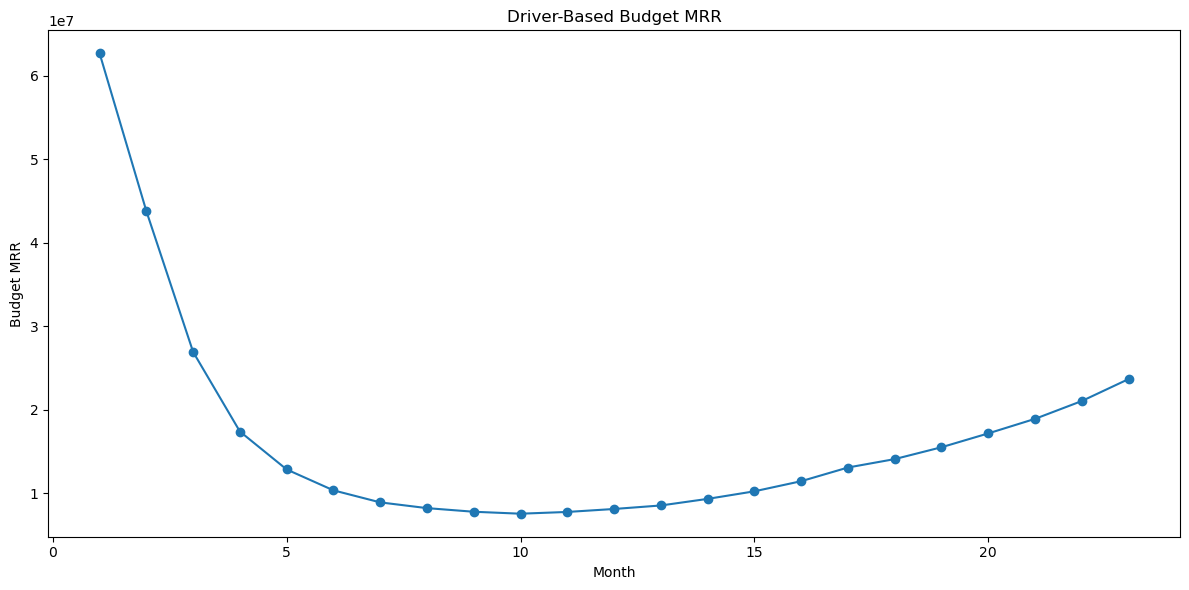

In [162]:
# BUDGET MRR TREND
plt.figure(figsize=(12, 6))
plt.plot(budget["month"], budget["budget_mrr"], marker="o")
plt.title("Driver-Based Budget MRR")
plt.xlabel("Month")
plt.ylabel("Budget MRR")

plt.tight_layout()
plt.show()

Interpretation: The driver-based budget projects total MRR of ₹385.87M using 50,000 accounts and a 4.27% growth assumption, with budgeted MRR recovering from Month 10 onward alongside improving average MRR per account.

### Phase 5 - Driver-Based Revenue Budget: Conclusion
- **Budget Assumption:** A **4.27% monthly growth rate** was selected using historical median MRR growth as a stable planning benchmark.
- **Revenue Budget:** The driver-based model projects **₹385.87M total MRR**, based on 50,000 accounts and expected average MRR per account.
- **Planning Insight:** The budget reflects the historical recovery pattern, with MRR expected to strengthen from Month 10 onward.

### Phase 6 - Actual vs Budget

In [169]:
# ACTUAL VS BUDGET VARIANCE
variance = budget.merge(
    monthly_mrr[
        ["month", "total_current_mrr"]], on="month", how="left")
variance["actual_mrr"] = variance["total_current_mrr"]
# Revenue variance
variance["revenue_variance"] = (
    variance["actual_mrr"] -
    variance["budget_mrr"])
# Variance %
variance["variance_pct"] = (
    variance["revenue_variance"] /
    variance["budget_mrr"]) * 100
# Favorable / Unfavorable
variance["variance_status"] = np.where(
    variance["revenue_variance"] >= 0, "Favorable", "Unfavorable")
display(
    variance[
        [
            "month",
            "budget_mrr",
            "actual_mrr",
            "revenue_variance",
            "variance_pct",
            "variance_status"
        ]
    ]
)

,month,budget_mrr,actual_mrr,revenue_variance,variance_pct,variance_status
0,1,6.270390e+07,6.013696e+07,-2.566943e+06,-4.093754,Unfavorable
1,2,4.380795e+07,4.201456e+07,-1.793389e+06,-4.093754,Unfavorable
2,3,2.694189e+07,2.583895e+07,-1.102935e+06,-4.093754,Unfavorable
3,4,1.741613e+07,1.670316e+07,-7.129735e+05,-4.093754,Unfavorable
4,5,1.287125e+07,1.234433e+07,-5.269171e+05,-4.093754,Unfavorable
5,6,1.037192e+07,9.947318e+06,-4.246008e+05,-4.093754,Unfavorable
6,7,8.930736e+06,8.565133e+06,-3.656023e+05,-4.093754,Unfavorable
7,8,8.242950e+06,7.905504e+06,-3.374461e+05,-4.093754,Unfavorable
8,9,7.808811e+06,7.489138e+06,-3.196735e+05,-4.093754,Unfavorable
9,10,7.574709e+06,7.264619e+06,-3.100899e+05,-4.093754,Unfavorable


In [173]:
# Overall Variance Summary
print("Budget vs Actual Summary")
print(f"Total Budget MRR : {variance['budget_mrr'].sum():,.2f}")
print(f"Total Actual MRR : {variance['actual_mrr'].sum():,.2f}")
print(f"Total Variance   : {variance['revenue_variance'].sum():,.2f}")

overall_variance_pct = (
    variance["revenue_variance"].sum()
    / variance["budget_mrr"].sum()) * 100
print(f"Overall Variance %: {overall_variance_pct:.2f}%")
print("\nVariance Classification:")
print(variance["variance_status"].value_counts())

Budget vs Actual Summary
Total Budget MRR : 385,870,771.58
Total Actual MRR : 370,074,173.00
Total Variance   : -15,796,598.58
Overall Variance %: -4.09%

Variance Classification:
variance_status
Unfavorable    23
Name: count, dtype: int64


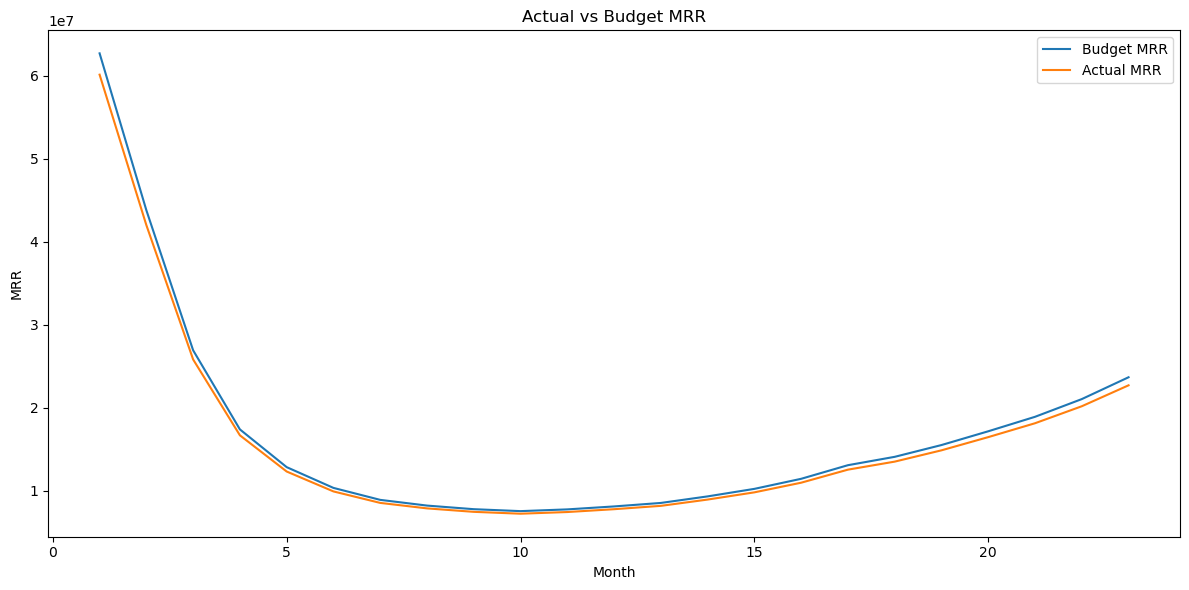

In [175]:
# ACTUAL VS BUDGET
plt.figure(figsize=(12, 6))
plt.plot(variance["month"], variance["budget_mrr"], label="Budget MRR")
plt.plot(variance["month"], variance["actual_mrr"], label="Actual MRR")
plt.title("Actual vs Budget MRR")
plt.xlabel("Month")
plt.ylabel("MRR")
plt.legend()
plt.tight_layout()
plt.show()

Interpretation: Actual MRR was consistently 4.09% below budget across all 23 months, resulting in an overall unfavorable variance of ₹15.80M, indicating that the 4.27% budget growth assumption was slightly optimistic.

In [178]:
# REVENUE VARIANCE DRIVERS
variance_drivers = budget.merge(
    monthly_mrr[["month", "accounts", "average_mrr_per_account"]],
    on="month",
    suffixes=("_budget", "_actual"))
variance_drivers["account_variance"] = (
    variance_drivers["accounts_actual"] -
    variance_drivers["budget_accounts"])
variance_drivers["avg_mrr_variance"] = (
    variance_drivers["average_mrr_per_account_actual"] -
    variance_drivers["budget_average_mrr"])
display(variance_drivers.head())

,month,accounts_budget,average_mrr_per_account_budget,budget_accounts,budget_average_mrr,budget_mrr,accounts_actual,average_mrr_per_account_actual,account_variance,avg_mrr_variance
0,1,50000,1202.739147,50000,1254.078010,6.270390e+07,50000,1202.739147,0,-51.338864
1,2,50000,840.291175,50000,876.158964,4.380795e+07,50000,840.291175,0,-35.867789
2,3,50000,516.779091,50000,538.837782,2.694189e+07,50000,516.779091,0,-22.058691
3,4,50000,334.063159,50000,348.322629,1.741613e+07,50000,334.063159,0,-14.259470
4,5,50000,246.886602,50000,257.424945,1.287125e+07,50000,246.886602,0,-10.538343


In [182]:
contract_mix = (
    saas_data
    .groupby("contract_type")
    .agg(
        accounts=("account_id", "nunique"),
        total_mrr=("current_mrr", "sum"),
        average_mrr=("current_mrr", "mean"),
        average_usage_growth=("usage_growth", "mean"),
        average_discount=("discount_pct", "mean")))
display(contract_mix)

,accounts,total_mrr,average_mrr,average_usage_growth,average_discount
contract_type,,,,,
Annual,3706,1.578229e+08,1851.555421,0.012721,0.058287
Monthly,46294,2.122513e+08,199.341535,0.012809,0.058308


In [184]:
# Usage & Discount Drivers
driver_summary = pd.DataFrame({
    "Metric": [
        "Average Usage Growth",
        "Average Discount",
        "Average Payment Delay Rate",
        "Average Feature Adoption"],
    "Value": [
        saas_data["usage_growth"].mean(),
        saas_data["discount_pct"].mean(),
        saas_data["payment_delay_flag"].mean(),
        saas_data["feature_adoption_rate"].mean()]})
display(driver_summary)

,Metric,Value
0,Average Usage Growth,0.012803
1,Average Discount,0.058306
2,Average Payment Delay Rate,0.271859
3,Average Feature Adoption,0.500057


In [186]:
print("Revenue Variance Driver Summary")
print(
    f"Account Variance: "
    f"{variance_drivers['account_variance'].sum():,.0f}")
print(
    f"Average MRR Variance: "
    f"{variance_drivers['avg_mrr_variance'].mean():,.2f}")
print(
    f"Overall Revenue Variance: "
    f"{variance['revenue_variance'].sum():,.2f}")

Revenue Variance Driver Summary
Account Variance: 0
Average MRR Variance: -13.74
Overall Revenue Variance: -15,796,598.58


Interpretation: The unfavorable ₹15.80M revenue variance is driven entirely by lower-than-budget average MRR per account, as account volume matched budget exactly; contract mix, usage growth and discounts were relatively stable.

### Phase 6 - Actual vs Budget: Conclusion
 - Variance: Actual MRR was 4.09% below budget, creating a ₹15.80M unfavorable variance.
 - Primary Driver: The variance was entirely attributable to lower average MRR per account, while account volume matched budget.
 - Management Insight: Revenue planning should focus on improving MRR per account/customer value, rather than increasing account volume alone.

### Phase 7 - FORECASTING

In [191]:
# GROWTH-BASED MRR FORECAST
# Use the latest actual MRR as the forecast starting point
last_actual_mrr = monthly_mrr["total_current_mrr"].iloc[-1]
forecast_months = 6
growth_forecast = []
current_value = last_actual_mrr
for i in range(1, forecast_months + 1):
    current_value = current_value * (1 + budget_growth_rate)
    growth_forecast.append({
        "month": monthly_mrr["month"].max() + i,
        "growth_forecast_mrr": current_value})
growth_forecast = pd.DataFrame(growth_forecast)
display(growth_forecast)

,month,growth_forecast_mrr
0,24,2.369646e+07
1,25,2.470794e+07
2,26,2.576260e+07
3,27,2.686227e+07
4,28,2.800888e+07
5,29,2.920444e+07


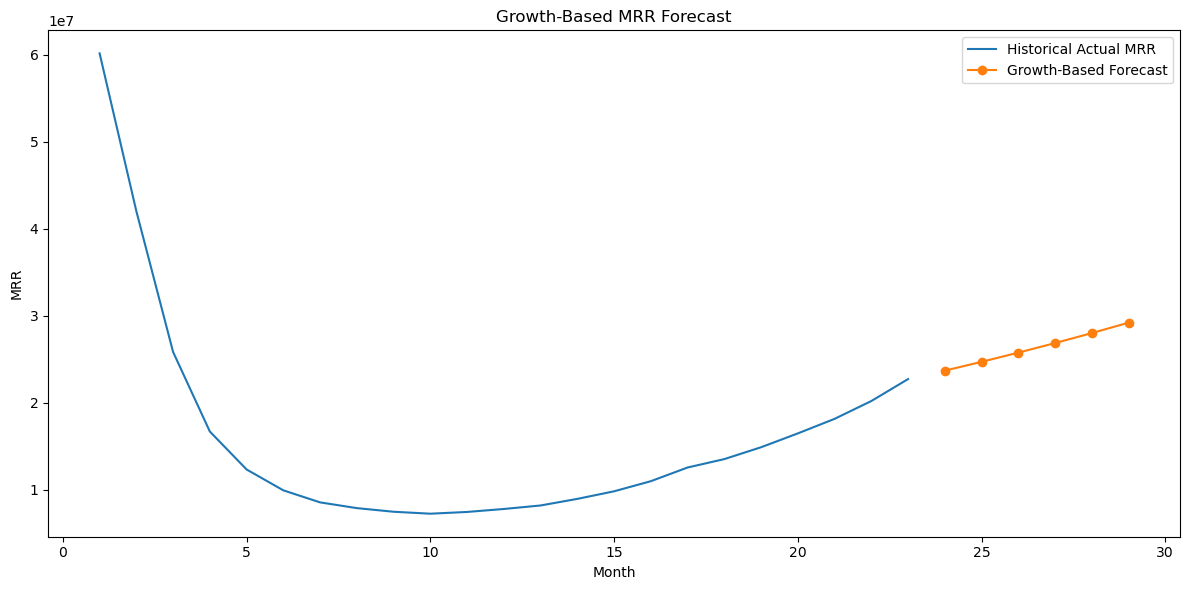

In [193]:
# GROWTH-BASED FORECAST Visualization
plt.figure(figsize=(12, 6))
plt.plot(monthly_mrr["month"], monthly_mrr["total_current_mrr"], label="Historical Actual MRR")
plt.plot(growth_forecast["month"], growth_forecast["growth_forecast_mrr"], marker="o", label="Growth-Based Forecast")
plt.title("Growth-Based MRR Forecast")
plt.xlabel("Month")
plt.ylabel("MRR")
plt.legend()
plt.tight_layout()
plt.show()

Interpretation: Using the 4.27% historical median growth assumption, MRR is forecast to increase from ₹23.70M in Month 23 to approximately ₹29.20M by Month 29, indicating continued revenue growth.

In [196]:
# MOVING AVERAGE FORECAST
mrr_history = monthly_mrr[
    ["month", "total_current_mrr"]
].copy()
mrr_history["moving_average_3m"] = (
    mrr_history["total_current_mrr"]
    .rolling(window=3)
    .mean())
display(mrr_history.tail())

,month,total_current_mrr,moving_average_3m
18,19,1.489711e+07,1.366775e+07
19,20,1.648714e+07,1.497343e+07
20,21,1.815824e+07,1.651416e+07
21,22,2.020459e+07,1.828333e+07
22,23,2.272638e+07,2.036307e+07


In [198]:
# 3-MONTH MOVING AVERAGE FORECAST
last_3_mrr = list(
    mrr_history["total_current_mrr"].tail(3))
ma_forecast = []
for i in range(1, 7):
    next_value = np.mean(last_3_mrr[-3:])
    ma_forecast.append({
        "month": monthly_mrr["month"].max() + i,
        "moving_average_forecast_mrr": next_value})
    last_3_mrr.append(next_value)
ma_forecast = pd.DataFrame(ma_forecast)
display(ma_forecast)

,month,moving_average_forecast_mrr
0,24,2.036307e+07
1,25,2.109802e+07
2,26,2.139582e+07
3,27,2.095230e+07
4,28,2.114871e+07
5,29,2.116561e+07


Interpretation: The 3-month moving-average forecast projects MRR around ₹20.4M–₹21.4M over the next six months, indicating relatively stable growth compared with the more optimistic growth-based forecast.

In [205]:
# TREND-BASED MRR FORECAST
# Historical data
X = monthly_mrr[["month"]]
y = monthly_mrr["total_current_mrr"]
# Fit linear trend model
trend_model = LinearRegression()
trend_model.fit(X, y)
# Forecast next 6 months
future_months = pd.DataFrame({
    "month": range(
        monthly_mrr["month"].max() + 1,
        monthly_mrr["month"].max() + 7)})
future_months["trend_forecast_mrr"] = (
    trend_model.predict(future_months[["month"]]))
display(future_months)

,month,trend_forecast_mrr
0,24,8.768252e+06
1,25,8.158091e+06
2,26,7.547930e+06
3,27,6.937770e+06
4,28,6.327609e+06
5,29,5.717448e+06


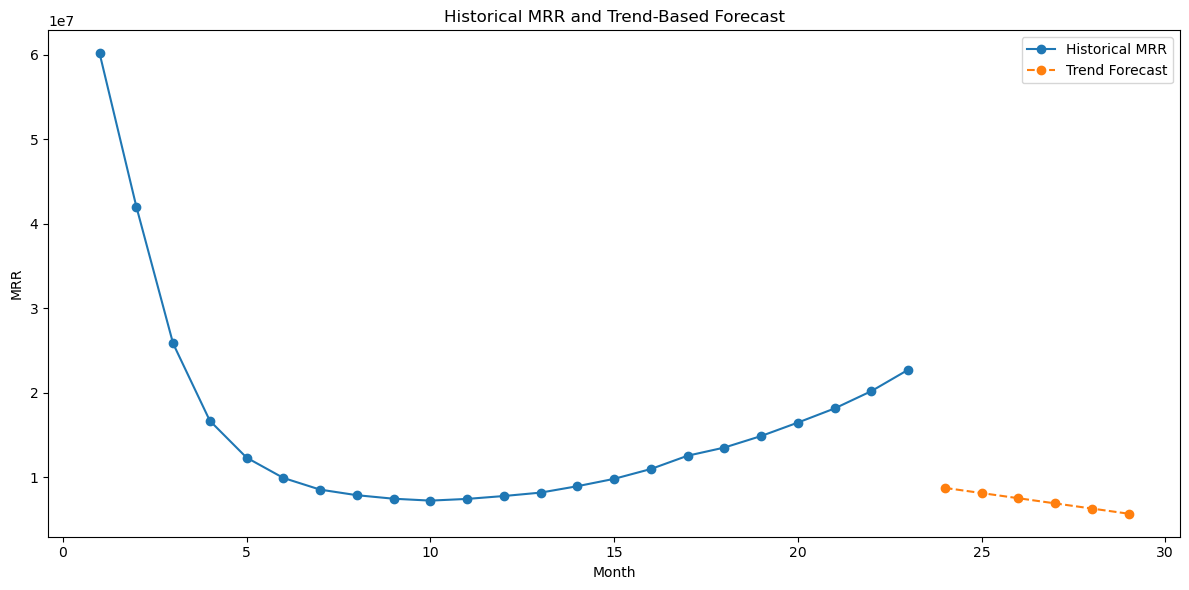

In [207]:
# TREND FORECAST VISUALIZATION
plt.figure(figsize=(12, 6))
plt.plot(monthly_mrr["month"], monthly_mrr["total_current_mrr"], marker="o", label="Historical MRR")
plt.plot(future_months["month"], future_months["trend_forecast_mrr"], marker="o", linestyle="--", label="Trend Forecast")
plt.title("Historical MRR and Trend-Based Forecast")
plt.xlabel("Month")
plt.ylabel("MRR")
plt.legend()
plt.tight_layout()
plt.show()

In [209]:
# TREND MODEL PERFORMANCE
r_squared = trend_model.score(X, y)
print("Trend Model Summary")
print(f"R-squared: {r_squared:.4f}")
print(f"Slope: {trend_model.coef_[0]:,.2f}")

Trend Model Summary
R-squared: 0.1095
Slope: -610,160.78


Interpretation: The trend model indicates a weak downward relationship (R² = 0.1095), forecasting MRR to decline from ₹8.77M in Month 24 to ₹5.72M by Month 29; therefore, the linear trend provides a relatively weak basis for management forecasting.

In [222]:
# FORECAST EVALUATION
# 1. Training and validation data
validation_size = 6
train = monthly_mrr.iloc[:-validation_size].copy()
validation = monthly_mrr.iloc[-validation_size:].copy()
actual = validation["total_current_mrr"].values
# 2. Growth-Based Forecast
growth_rate = train["mrr_growth_pct"].median() / 100
growth_predictions = []
last_value = train["total_current_mrr"].iloc[-1]
for _ in range(validation_size):
    last_value = last_value * (1 + growth_rate)
    growth_predictions.append(last_value)
# 3. Moving Average Forecast
history = list(train["total_current_mrr"])
ma_predictions = []
for i in range(validation_size):
    prediction = np.mean(history[-3:])
    ma_predictions.append(prediction)
# Add actual value for rolling validation
    history.append(validation["total_current_mrr"].iloc[i])
# 4. Trend-Based Forecast
trend_model = LinearRegression()
trend_model.fit(
    train[["month"]],
    train["total_current_mrr"])
trend_predictions = trend_model.predict(
    validation[["month"]])
# 5. Forecast Evaluation Function
def evaluate_forecast(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(
        mean_squared_error(actual, predicted))
    mape = np.mean(
        np.abs((actual - predicted) / actual)) * 100
    return mae, rmse, mape
# 6. Evaluate All Methods
results = []
methods = {
    "Growth-Based": growth_predictions,
    "Moving Average": ma_predictions,
    "Trend-Based": trend_predictions}
for method, prediction in methods.items():
    mae, rmse, mape = evaluate_forecast(actual, prediction)
    results.append({"Method": method, "MAE": mae, "RMSE": rmse, "MAPE": mape})
forecast_evaluation = pd.DataFrame(results)
# Sort by MAPE
forecast_evaluation = forecast_evaluation.sort_values(
    "MAPE"
).reset_index(drop=True)
display(forecast_evaluation)

,Method,MAE,RMSE,MAPE
0,Moving Average,3.177977e+06,3.256109e+06,17.861799
1,Growth-Based,6.604357e+06,7.626589e+06,34.709242
2,Trend-Based,2.350424e+07,2.432971e+07,130.846415


In [224]:
# BEST FORECAST METHOD
best_method = forecast_evaluation.loc[0, "Method"]
print("Recommended Forecast Method:", best_method)
print(
    f"Lowest MAPE: "
    f"{forecast_evaluation.loc[0, 'MAPE']:.2f}%")

Recommended Forecast Method: Moving Average
Lowest MAPE: 17.86%


Interpretation: The 3-month Moving Average is the most suitable forecasting method, achieving the lowest MAE (₹3.18M), RMSE (₹3.26M) and MAPE (17.86%), making it the most reliable option for management planning among the three methods tested.

### Phase 7 - Forecasting Conclusion
 - **Growth-based**: Optimistic forecast, reaching ₹29.20M by Month 29.
 - **Moving Average**: More stable forecast, reaching ₹21.17M by Month 29.
 - **Trend-based**: Weak fit (R² = 0.1095) and produced the least reliable forecasts.
 - **Selected method**: 3-month Moving Average, based on the lowest validation errors.

### Phase 8 - Scenario Planning

In [229]:
# SCENARIO PLANNING
growth_rates = {
    "Worst Case": monthly_mrr["mrr_growth_pct"].quantile(0.25) / 100,
    "Base Case": monthly_mrr["mrr_growth_pct"].median() / 100,
    "Best Case": monthly_mrr["mrr_growth_pct"].quantile(0.75) / 100}
print("Scenario Growth Assumptions")
for scenario, rate in growth_rates.items():
    print(f"{scenario}: {rate:.2%}")

Scenario Growth Assumptions
Worst Case: -11.63%
Base Case: 4.27%
Best Case: 9.32%


In [231]:
# SCENARIO FORECAST
last_actual_mrr = monthly_mrr["total_current_mrr"].iloc[-1]
scenario_forecast = []
for scenario, rate in growth_rates.items():
    current_mrr = last_actual_mrr
    for i in range(1, 7):
        current_mrr = current_mrr * (1 + rate)
        scenario_forecast.append({
            "month": monthly_mrr["month"].max() + i,
            "scenario": scenario,
            "forecast_mrr": current_mrr})
scenario_forecast = pd.DataFrame(scenario_forecast)
display(scenario_forecast)

,month,scenario,forecast_mrr
0,24,Worst Case,2.008349e+07
1,25,Worst Case,1.774795e+07
2,26,Worst Case,1.568401e+07
3,27,Worst Case,1.386010e+07
4,28,Worst Case,1.224828e+07
5,29,Worst Case,1.082391e+07
6,24,Base Case,2.369646e+07
7,25,Base Case,2.470794e+07
8,26,Base Case,2.576260e+07
9,27,Base Case,2.686227e+07


In [233]:
scenario_table = scenario_forecast.pivot(
    index="month",
    columns="scenario",
    values="forecast_mrr")
display(scenario_table)

scenario,Base Case,Best Case,Worst Case
month,,,
24,2.369646e+07,2.484469e+07,2.008349e+07
25,2.470794e+07,2.716044e+07,1.774795e+07
26,2.576260e+07,2.969204e+07,1.568401e+07
27,2.686227e+07,3.245960e+07,1.386010e+07
28,2.800888e+07,3.548513e+07,1.224828e+07
29,2.920444e+07,3.879267e+07,1.082391e+07


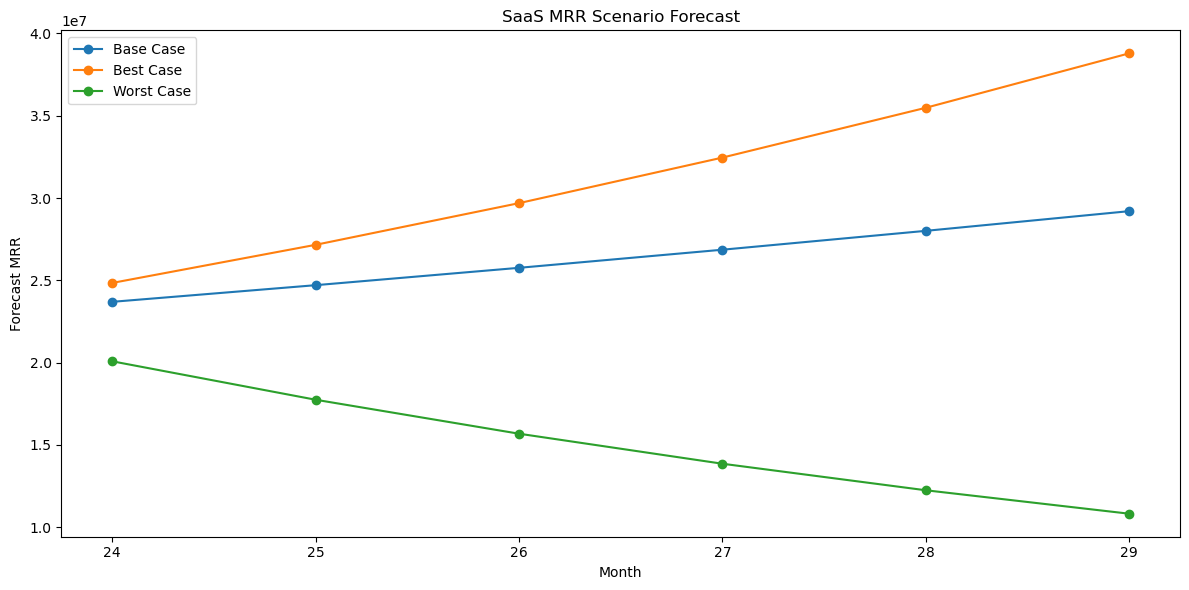

In [235]:
# SCENARIO FORECAST CHART
plt.figure(figsize=(12, 6))
for scenario in scenario_table.columns:
    plt.plot(
        scenario_table.index,
        scenario_table[scenario],
        marker="o",
        label=scenario)
plt.title("SaaS MRR Scenario Forecast")
plt.xlabel("Month")
plt.ylabel("Forecast MRR")
plt.legend()
plt.tight_layout()
plt.show()

Interpretation: Scenario analysis shows a wide revenue range: by Month 29, MRR could reach ₹10.82M in the Worst Case, ₹29.20M in the Base Case, or ₹38.79M in the Best Case, highlighting significant upside and downside risk.

Management Insight:The -11.63% Worst Case highlights the need for downside protection, while the 9.32% Best Case shows meaningful growth potential if positive revenue drivers are sustained.

In [239]:
# MRR SENSITIVITY ANALYSIS
sensitivity_rates = {
    "Low Growth": -0.1163,
    "Moderate Growth": 0.00,
    "Base Growth": 0.0427,
    "High Growth": 0.0932,
    "Very High Growth": 0.15}
last_actual_mrr = monthly_mrr["total_current_mrr"].iloc[-1]
sensitivity_results = []
for scenario, rate in sensitivity_rates.items():
    projected_mrr = last_actual_mrr * (1 + rate) ** 6
    sensitivity_results.append({
        "Growth Scenario": scenario,
        "Growth Rate": rate,
        "Month_29_MRR": projected_mrr})
sensitivity_df = pd.DataFrame(sensitivity_results)
display(sensitivity_df)

,Growth Scenario,Growth Rate,Month_29_MRR
0,Low Growth,-0.1163,1.082329e+07
1,Moderate Growth,0.0000,2.272638e+07
2,Base Growth,0.0427,2.920697e+07
3,High Growth,0.0932,3.879074e+07
4,Very High Growth,0.1500,5.256750e+07


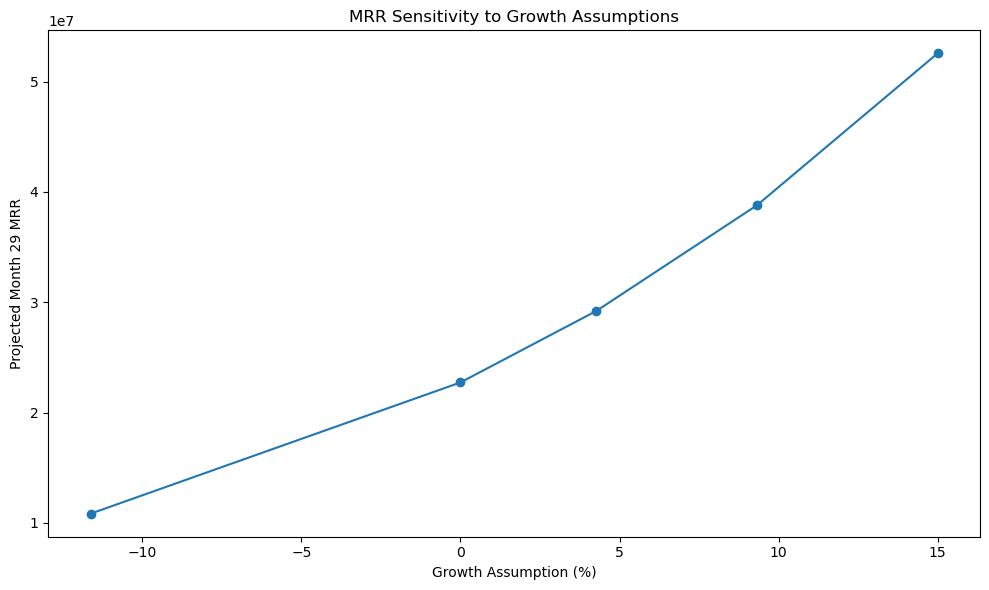

In [241]:
# SENSITIVITY CHART
plt.figure(figsize=(10, 6))
plt.plot(
    sensitivity_df["Growth Rate"] * 100,
    sensitivity_df["Month_29_MRR"],
    marker="o")
plt.title("MRR Sensitivity to Growth Assumptions")
plt.xlabel("Growth Assumption (%)")
plt.ylabel("Projected Month 29 MRR")
plt.tight_layout()
plt.show()

Interpretation: The sensitivity analysis shows that Month 29 MRR is highly dependent on the growth assumption, ranging from ₹10.82M at -11.63% growth to ₹52.57M at 15% growth, indicating substantial downside and upside exposure.

### Phase 8 - Scenario Planning Conclusion
 - Future MRR shows significant uncertainty, ranging from **₹10.82M in the Worst Case** to **₹29.20M in the Base Case** and **₹38.79M in the Best Case** by Month 29.
 - MRR is highly sensitive to growth assumptions, with projected Month 29 MRR ranging from **₹10.82M to ₹52.57M** across the tested scenarios.
 - **Overall:** Management should use **scenario-based planning** rather than relying on a single forecast, while closely monitoring the revenue drivers that can influence growth.

### Phase 9 - Management Dashboard

In [252]:
# FP&A MANAGEMENT DASHBOARD KPI SUMMARY
# Latest Actual MRR
latest_actual_mrr = monthly_mrr["total_current_mrr"].iloc[-1]
# Latest Budget MRR
latest_budget_mrr = budget["budget_mrr"].iloc[-1]
# Latest Revenue Variance %
latest_variance_pct = (
    (latest_actual_mrr - latest_budget_mrr)
    / latest_budget_mrr
) * 100
# Overall MRR Growth
overall_mrr_growth = (
    (monthly_mrr["total_current_mrr"].iloc[-1]
     - monthly_mrr["total_current_mrr"].iloc[0])
    / monthly_mrr["total_current_mrr"].iloc[0]
) * 100
# Latest Account Count
latest_accounts = monthly_mrr["accounts"].iloc[-1]
# Average MRR per Account
average_mrr_account = average_mrr_per_account
# Revenue per Active User
avg_revenue_per_user = revenue_per_active_user
# Average Usage Growth
avg_usage_growth = average_usage_growth * 100
# Payment Delay Rate
payment_delay_rate = payment_delay_rate
# Selected Forecast — Moving Average
forecast_mrr = ma_forecast[
    "moving_average_forecast_mrr"
].iloc[-1]
# Dashboard KPI Table
dashboard_kpis = pd.DataFrame({
    "KPI": [
        "Latest Actual MRR",
        "Latest Budget MRR",
        "Revenue Variance %",
        "Overall MRR Growth %",
        "Accounts",
        "Average MRR / Account",
        "Revenue / Active User",
        "Usage Growth %",
        "Payment Delay Rate %",
        "Forecast MRR"],
    "Value": [
        latest_actual_mrr,
        latest_budget_mrr,
        latest_variance_pct,
        overall_mrr_growth,
        latest_accounts,
        average_mrr_account,
        avg_revenue_per_user,
        avg_usage_growth,
        payment_delay_rate,
        forecast_mrr]})
display(dashboard_kpis)

,KPI,Value
0,Latest Actual MRR,2.272638e+07
1,Latest Budget MRR,2.369646e+07
2,Revenue Variance %,-4.093754e+00
3,Overall MRR Growth %,-6.220896e+01
4,Accounts,5.000000e+04
5,Average MRR / Account,3.218036e+02
6,Revenue / Active User,3.586755e+00
7,Usage Growth %,1.280262e+00
8,Payment Delay Rate %,2.718591e+01
9,Forecast MRR,2.116561e+07


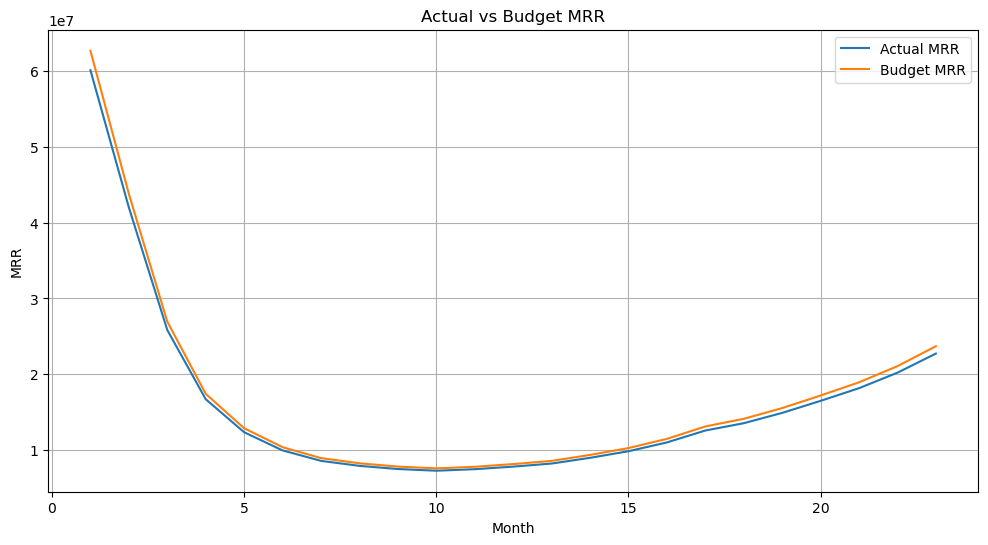

In [254]:
# ACTUAL VS BUDGET MRR
plt.figure(figsize=(12, 6))
plt.plot(
    monthly_mrr["month"],
    monthly_mrr["total_current_mrr"],
    label="Actual MRR")
plt.plot(
    budget["month"],
    budget["budget_mrr"],
    label="Budget MRR")
plt.title("Actual vs Budget MRR")
plt.xlabel("Month")
plt.ylabel("MRR")
plt.legend()
plt.grid(True)
plt.show()

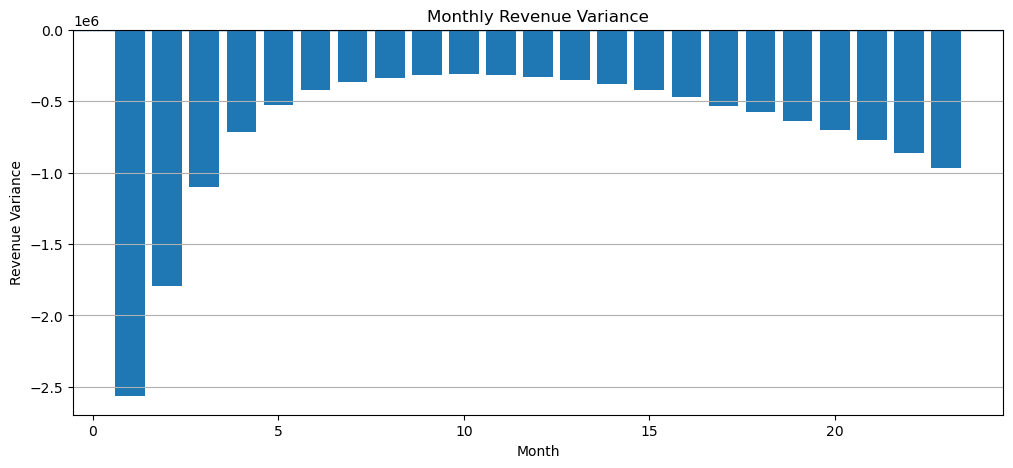

In [256]:
# REVENUE VARIANCE
plt.figure(figsize=(12, 5))
plt.bar(
    variance["month"],
    variance["revenue_variance"])
plt.axhline(0, linewidth=1)
plt.title("Monthly Revenue Variance")
plt.xlabel("Month")
plt.ylabel("Revenue Variance")
plt.grid(axis="y")
plt.show()

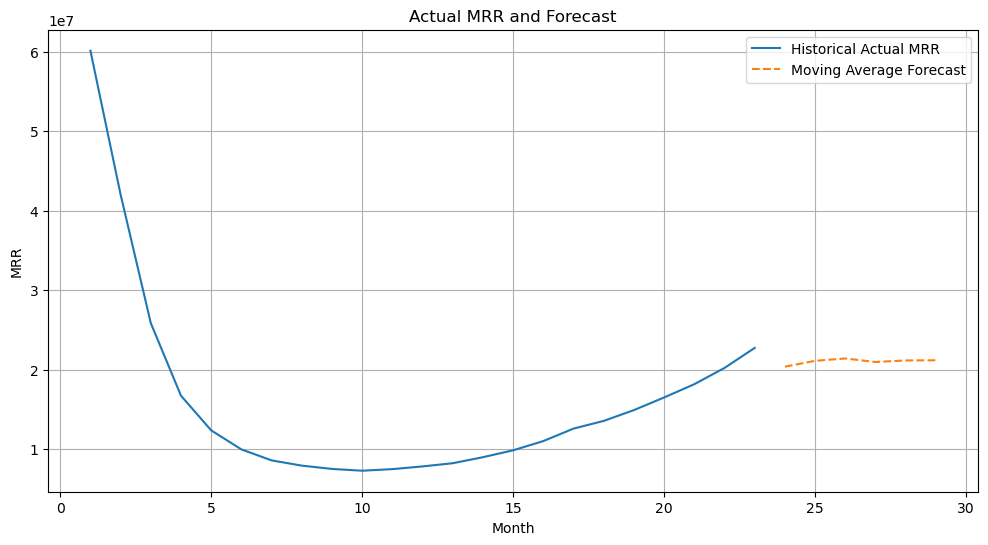

In [258]:
# ACTUAL MRR + FORECAST
plt.figure(figsize=(12, 6))
plt.plot(
    monthly_mrr["month"],
    monthly_mrr["total_current_mrr"],
    label="Historical Actual MRR")
plt.plot(
    ma_forecast["month"],
    ma_forecast["moving_average_forecast_mrr"],
    linestyle="--",
    label="Moving Average Forecast")
plt.title("Actual MRR and Forecast")
plt.xlabel("Month")
plt.ylabel("MRR")
plt.legend()
plt.grid(True)
plt.show()

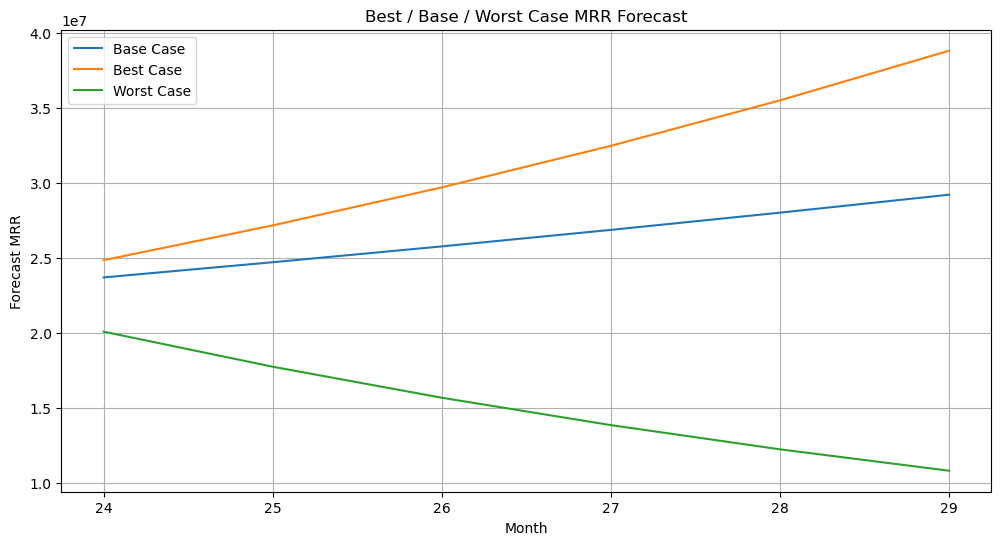

In [262]:
# SCENARIO FORECAST
plt.figure(figsize=(12, 6))
plt.plot(
    scenario_table.index,
    scenario_table["Base Case"],
    label="Base Case")
plt.plot(
    scenario_table.index,
    scenario_table["Best Case"],
    label="Best Case")
plt.plot(
    scenario_table.index,
    scenario_table["Worst Case"],
    label="Worst Case")
plt.title("Best / Base / Worst Case MRR Forecast")
plt.xlabel("Month")
plt.ylabel("Forecast MRR")
plt.legend()
plt.grid(True)
plt.show()

Management Dashboard Summary: Actual MRR is below budget by 4.09%, while historical revenue performance remains volatile. The Moving Average model provides the most reliable forecast among the tested methods, with projected MRR of approximately ₹21.17M. Scenario analysis highlights substantial upside and downside risk, indicating that management should closely monitor customer payment behavior, usage, and revenue-per-account performance.

#### Management Dashboard Conclusion
 - **Revenue**: Actual MRR is ₹22.73M, below the latest budget of ₹23.70M, resulting in a 4.09% unfavorable variance.
 - **Growth**: Overall MRR has declined significantly across the historical period, indicating revenue volatility and pressure on recurring revenue.
 - **Forecast**: The recommended Moving Average model projects approximately ₹21.17M MRR for the next period.
 - **Business health**: Payment delays remain notable at 27.19%, while average usage growth is only 1.28%.
 - **Planning risk**: Scenario analysis shows substantial upside and downside potential, so management should monitor revenue drivers closely and use scenario-based planning.

### Phase 10 - Management Recommendations

#### 1. Revenue Performance
Recurring revenue shows a **volatile pattern**, with MRR declining substantially during the early periods before recovering in later months. Overall historical MRR growth remains negative, indicating that revenue stability is a key management concern.
#### 2. Actual vs Budget
Actual MRR is **₹370.07M** versus a budget of **₹385.87M**, resulting in a **₹15.80M unfavorable variance (-4.09%)**. The variance occurs consistently across all 23 periods.
#### 3. Major Variance Drivers
The account base remains constant at **50000 accounts**, while actual average MRR per account is consistently below the budget assumption. Therefore, the revenue shortfall is primarily associated with **lower revenue per account rather than customer volume**.
#### 4. Revenue Segments
**Enterprise customers** contribute the largest MRR because of their substantially higher average MRR per account. Among industries, **EdTech and Energy** generate the highest total MRR, making them important segments for revenue planning.
#### 5. Operational Revenue Drivers
Higher usage growth is associated with higher MRR, while payment delays are associated with substantially lower MRR. Contract structure also matters: Annual customers have much higher average MRR than Monthly customers.
#### 6. Forecast Outlook
The **Moving Average model** is the preferred forecasting approach, achieving the lowest validation error with **17.86% MAPE**. It forecasts approximately **₹21.17M** MRR for the next period.
#### 7. Upside & Downside Risk
Scenario analysis shows considerable uncertainty. By Month 29, projected MRR ranges from approximately **₹10.82M under the worst case to ₹38.79M under the best case**, demonstrating significant sensitivity to revenue growth assumptions.
#### 8. Management Actions
 - **Improve revenue per account:** Focus on Enterprise and high-value customer segments to increase account-level MRR.
 - **Reduce payment delays:** Prioritize customers with payment delays because delayed payments are associated with substantially lower future MRR.
 - **Increase product engagement:** Encourage higher usage and feature adoption through targeted customer-success initiatives.
 - **Review the budget assumption:** The consistent **4.09% unfavorable variance** suggests that the current budget may be somewhat optimistic.
 - **Use rolling forecasts:** Update the forecast regularly using actual MRR performance rather than relying solely on the original annual assumption.
 - **Adopt scenario planning:** Maintain Base, Best, and Worst cases to prepare management for changing revenue conditions.
### Final Executive Conclusion
**The SaaS business shows improving MRR momentum in the later periods but remains below budget, with the shortfall driven primarily by lower revenue per account rather than customer volume. Management should prioritize enterprise expansion, payment-risk reduction, customer engagement and rolling forecast updates while using scenario-based planning to manage revenue uncertainty.**